In [24]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully. ✅")

Libraries imported successfully. ✅


Load integrated dataset

Why: Use the final dataset created by 01_dataset_integration.ipynb.

In [25]:
# Load the integrated dataset

df = pd.read_csv(
    "../data/processed/integrated_startup_data.csv"
)

print("Dataset loaded successfully. ✅")
print("Shape:", df.shape)

Dataset loaded successfully. ✅
Shape: (1383, 14)


View first records

Why: Quickly verify that the dataset loaded correctly.

In [26]:
# Display the first five records

display(df.head())

,company,founded_year,sector,subsector,country,city,funding_usd_millions,valuation_usd_millions,employees,startup_stage,profitable,is_unicorn,data_source,company_key
0,DeepMind,2010,Foundation Model / Research,AI Research Lab,United Kingdom,London,500.0,NaN,400,Acquisition,False,NaN,Funding Dataset,deepmind
1,OpenAI,2015,Foundation Model / LLM,General-Purpose AI,United States,San Francisco,1000.0,NaN,120,Strategic Investment,False,NaN,Funding Dataset,openai
2,Palantir,2003,AI Application,Data Analytics / Defense AI,United States,Denver,0.0,15800.0,2400,Direct Listing,True,NaN,Funding Dataset,palantir
3,UiPath,2005,AI Application,Robotic Process Automation,United States,New York,1340.0,35800.0,4000,IPO,False,NaN,Funding Dataset,uipath
4,SenseTime,2014,AI Application,Computer Vision / Smart City,China,Hong Kong,740.0,16800.0,6000,IPO,False,NaN,Funding Dataset,sensetime


Check columns

Why: Confirm the standardized columns we will use throughout the project.

In [27]:
# Display column names

print(df.columns.tolist())

['company', 'founded_year', 'sector', 'subsector', 'country', 'city', 'funding_usd_millions', 'valuation_usd_millions', 'employees', 'startup_stage', 'profitable', 'is_unicorn', 'data_source', 'company_key']


Dataset information

Why: Check data types and non-null values.

In [28]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company                 1383 non-null   object 
 1   founded_year            1383 non-null   int64  
 2   sector                  1383 non-null   object 
 3   subsector               150 non-null    object 
 4   country                 1383 non-null   object 
 5   city                    1383 non-null   object 
 6   funding_usd_millions    150 non-null    float64
 7   valuation_usd_millions  1376 non-null   float64
 8   employees               150 non-null    object 
 9   startup_stage           1383 non-null   object 
 10  profitable              38 non-null     object 
 11  is_unicorn              1345 non-null   object 
 12  data_source             1383 non-null   object 
 13  company_key             1383 non-null   object 
dtypes: float64(2), int64(1), object(11)
memo

Missing values

Why: Understand which features contain missing information.

In [29]:
# Check missing values

missing = df.isnull().sum()

print(missing)

company                      0
founded_year                 0
sector                       0
subsector                 1233
country                      0
city                         0
funding_usd_millions      1233
valuation_usd_millions       7
employees                 1233
startup_stage                0
profitable                1345
is_unicorn                  38
data_source                  0
company_key                  0
dtype: int64


Dataset source distribution

Why: See how many records came from each original dataset.

In [30]:
# Count records by data source

source_counts = df["data_source"].value_counts()

print(source_counts)

data_source
Unicorn Dataset     1233
India AI Dataset     112
Funding Dataset       38
Name: count, dtype: int64


Target Analysis
Unicorn distribution

Why: Understand the success/unicorn distribution in the integrated dataset.

In [31]:
# Count unicorn and non-unicorn records

print(
    df["is_unicorn"].value_counts(dropna=False)
)

is_unicorn
True     1244
False     101
NaN        38
Name: count, dtype: int64


Unicorn distribution chart

Why: Visualize the target distribution.

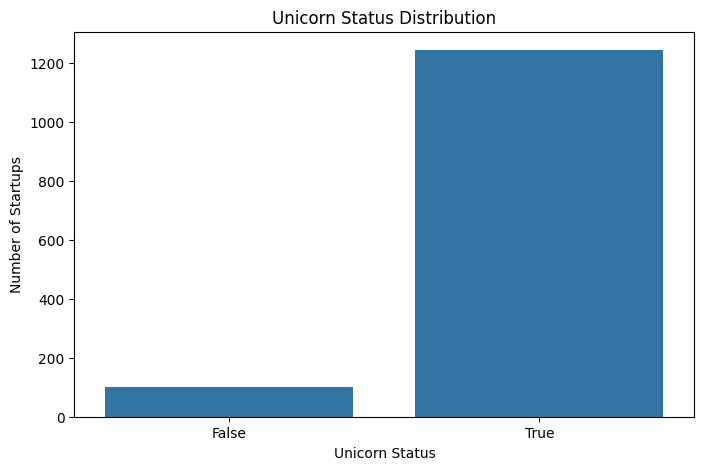

In [32]:
# Plot unicorn distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="is_unicorn"
)

plt.title("Unicorn Status Distribution")
plt.xlabel("Unicorn Status")
plt.ylabel("Number of Startups")

plt.show()

Sector Analysis
Sector distribution

Why: Understand which sectors are represented most in our data.

In [33]:
# Count startups by sector

sector_counts = df["sector"].value_counts()

print(sector_counts)

sector
Enterprise Tech                 388
Financial Services              220
Consumer & Retail               213
Industrials                     185
Healthcare & Life Sciences      117
Media & Entertainment            83
Enterprise AI                    31
Insurance                        26
Foundation Model / LLM           17
Fintech AI                       12
AI Application                   11
Media Tech                        8
HR Tech                           8
AI Infrastructure                 7
HealthTech                        5
Developer Tools                   5
Consumer AI                       4
Foundation Models                 4
MarTech                           4
Agentic AI                        4
Security                          3
Productivity                      3
Retail AI                         3
Logistics                         3
AgriTech                          3
EdTech                            2
Defence Tech                      2
AI for Physical World

Sector chart

Why: Visualize startup distribution across sectors.

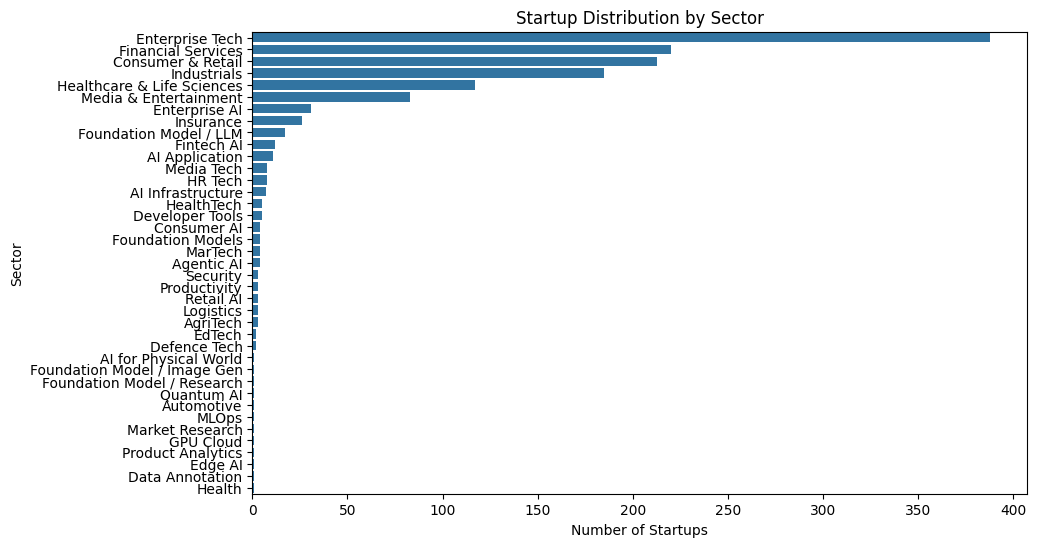

In [34]:
# Plot sector distribution

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="sector",
    order=sector_counts.index
)

plt.title("Startup Distribution by Sector")
plt.xlabel("Number of Startups")
plt.ylabel("Sector")

plt.show()

Startup Stage Analysis
Stage distribution

Why: Understand how startups are distributed across funding/growth stages.

In [35]:
# Count startups by stage

stage_counts = df["startup_stage"].value_counts()

print(stage_counts)

startup_stage
Unicorn                 1233
Growth Stage              57
Early Stage               33
Late Stage                15
Series C                   8
Acquired                   5
Series D                   4
Strategic Investment       4
Series B                   4
Series F                   3
Seed                       2
Listed                     2
IPO                        2
Series A                   2
Series E                   2
Acquisition                1
Direct Listing             1
Series I                   1
Growth Equity              1
Series E Extension         1
Seed / Launch              1
Series J                   1
Name: count, dtype: int64


Stage chart

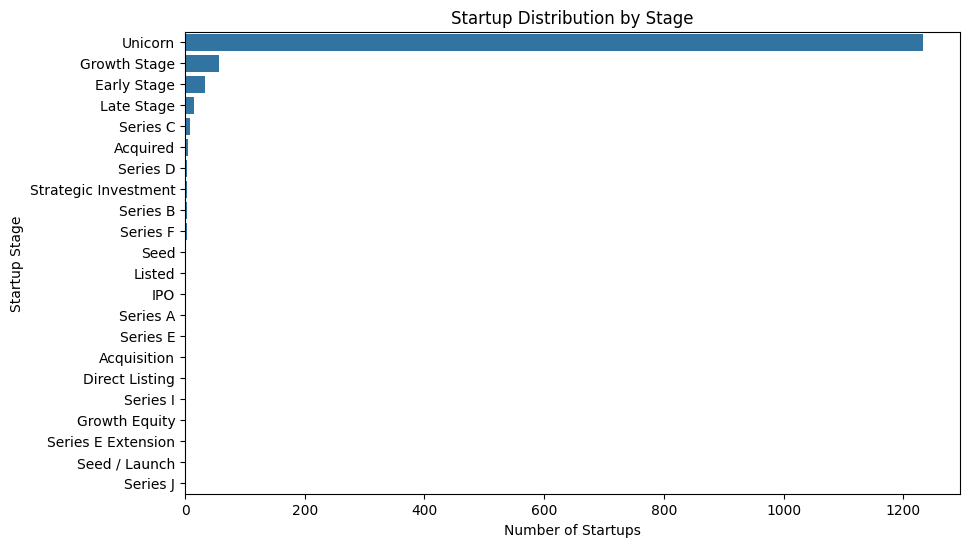

In [36]:
# Plot startup stage distribution

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="startup_stage",
    order=stage_counts.index
)

plt.title("Startup Distribution by Stage")
plt.xlabel("Number of Startups")
plt.ylabel("Startup Stage")

plt.show()

Country Analysis
Top countries

Why: Identify countries with the largest number of startups.

In [37]:
# Find the top 15 countries

country_counts = (
    df["country"]
    .value_counts()
    .head(15)
)

print(country_counts)

country
United States     687
India             183
China             169
United Kingdom     57
Germany            31
France             28
Israel             25
Canada             22
Singapore          17
Brazil             17
South Korea        15
Australia           9
Netherlands         9
Mexico              8
Hong Kong           7
Name: count, dtype: int64


Country chart

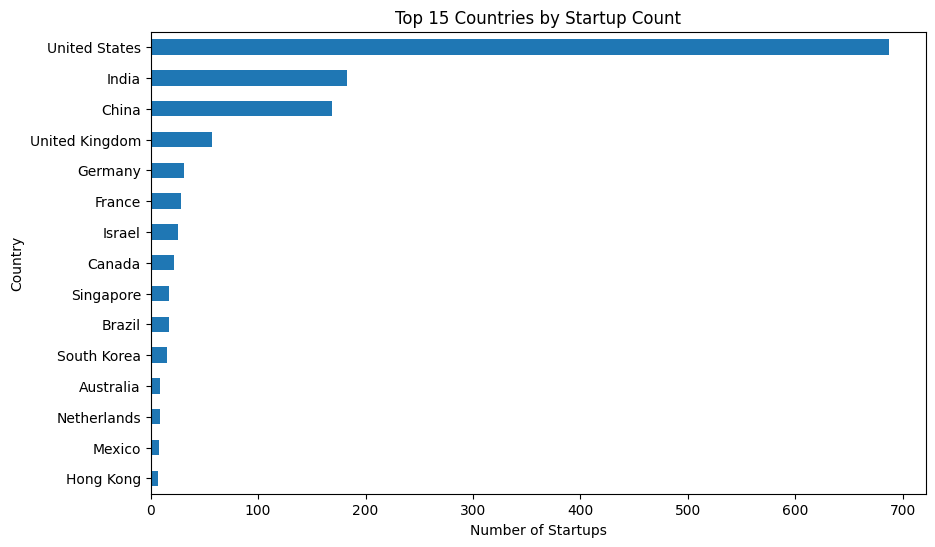

In [38]:
# Plot top 15 countries

plt.figure(figsize=(10,6))

country_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Countries by Startup Count")
plt.xlabel("Number of Startups")
plt.ylabel("Country")

plt.show()

Funding Analysis
Funding summary

Why: Understand the distribution of startup funding.

In [39]:
# Display funding statistics

print(
    df["funding_usd_millions"].describe()
)

count      150.000000
mean      1098.514267
std       3943.503463
min          0.000000
25%         12.000000
50%         47.000000
75%        292.500000
max      40000.000000
Name: funding_usd_millions, dtype: float64


Funding distribution

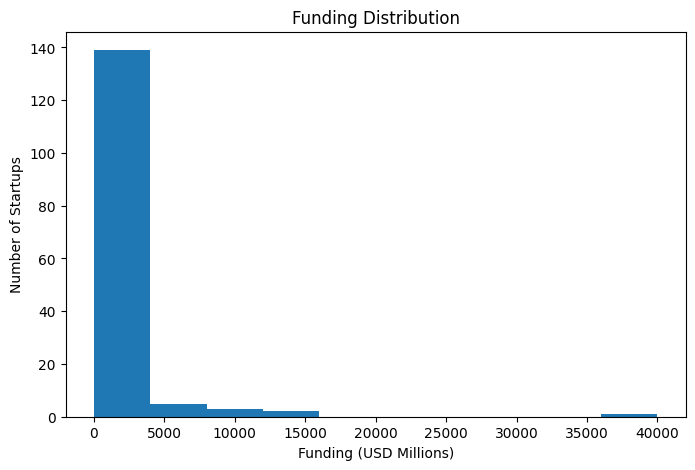

In [40]:
# Plot funding distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["funding_usd_millions"].dropna(),
    bins=10
)

plt.title("Funding Distribution")
plt.xlabel("Funding (USD Millions)")
plt.ylabel("Number of Startups")

plt.show()

Valuation Analysis
Valuation summary

Why: Understand the valuation range of the startups.

In [41]:
# Display valuation statistics

print(
    df["valuation_usd_millions"].describe()
)

count      1376.000000
mean       3925.603198
std       15064.142460
min           0.000000
25%        1000.000000
50%        1500.000000
75%        2905.000000
max      300000.000000
Name: valuation_usd_millions, dtype: float64


Valuation distribution

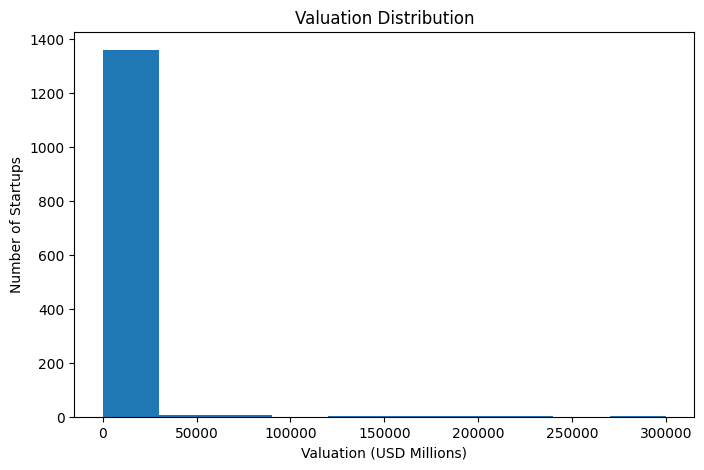

In [42]:
# Plot valuation distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["valuation_usd_millions"].dropna(),
    bins=10
)

plt.title("Valuation Distribution")
plt.xlabel("Valuation (USD Millions)")
plt.ylabel("Number of Startups")

plt.show()

Founded Year Analysis
Founded year distribution

Why: Understand when the startups in our dataset were founded.

In [43]:
# Display founded year statistics

print(
    df["founded_year"].describe()
)

count    1383.000000
mean     2020.161244
std         2.586708
min      1997.000000
25%      2019.000000
50%      2021.000000
75%      2022.000000
max      2025.000000
Name: founded_year, dtype: float64


Founded year chart

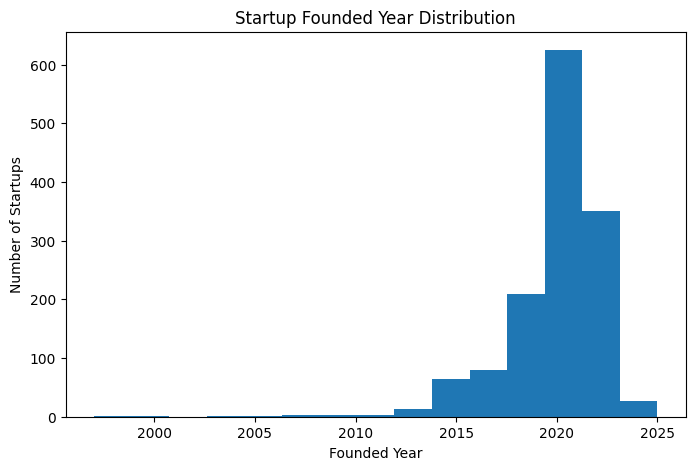

In [44]:
# Plot founded year distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["founded_year"].dropna(),
    bins=15
)

plt.title("Startup Founded Year Distribution")
plt.xlabel("Founded Year")
plt.ylabel("Number of Startups")

plt.show()

Funding vs Unicorn Status

Why: Check whether successful/unicorn startups tend to have different funding levels.

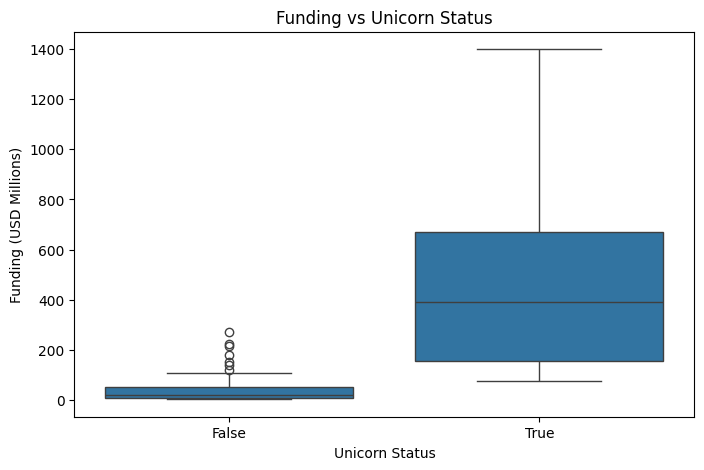

In [45]:
# Compare funding by unicorn status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_unicorn",
    y="funding_usd_millions"
)

plt.title("Funding vs Unicorn Status")
plt.xlabel("Unicorn Status")
plt.ylabel("Funding (USD Millions)")

plt.show()

Valuation vs Unicorn Status

Why: Compare valuation between unicorn and non-unicorn records.

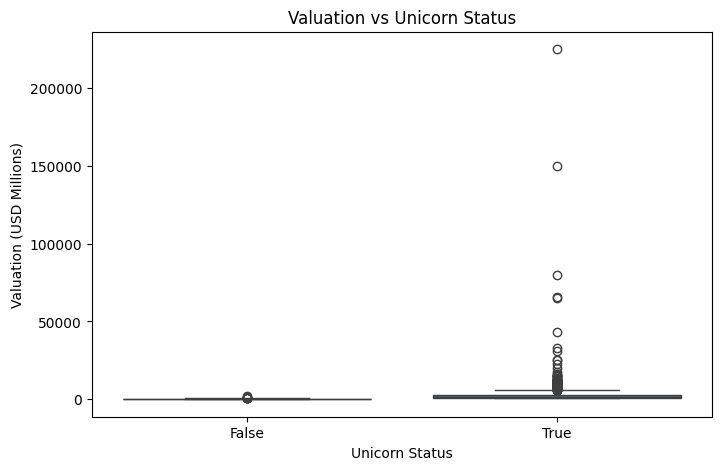

In [46]:
# Compare valuation by unicorn status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_unicorn",
    y="valuation_usd_millions"
)

plt.title("Valuation vs Unicorn Status")
plt.xlabel("Unicorn Status")
plt.ylabel("Valuation (USD Millions)")

plt.show()

Success by Sector

Why: Identify sectors with higher observed unicorn rates.

In [47]:
# Calculate unicorn rate by sector

sector_success = (
    df.groupby("sector")["is_unicorn"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

print(
    sector_success
)

sector
Enterprise Tech                    100.0
Media & Entertainment              100.0
Industrials                        100.0
Healthcare & Life Sciences         100.0
Health                             100.0
Financial Services                 100.0
Insurance                          100.0
Consumer & Retail                  100.0
MarTech                             50.0
HR Tech                             37.5
Foundation Models                   25.0
Consumer AI                         25.0
Enterprise AI                   9.677419
Fintech AI                      8.333333
Product Analytics                    0.0
Media Tech                           0.0
Productivity                         0.0
Logistics                            0.0
Quantum AI                           0.0
Market Research                      0.0
MLOps                                0.0
Retail AI                            0.0
Agentic AI                           0.0
HealthTech                           0.0
AgriTech 

Correlation Analysis

Why: Check relationships between numerical variables.

In [48]:
# Select numerical columns

numeric_df = df.select_dtypes(
    include="number"
)

print(
    numeric_df.corr()
)

                        founded_year  funding_usd_millions  \
founded_year                1.000000             -0.023993   
funding_usd_millions       -0.023993              1.000000   
valuation_usd_millions     -0.149450              0.861267   

                        valuation_usd_millions  
founded_year                         -0.149450  
funding_usd_millions                  0.861267  
valuation_usd_millions                1.000000  


Correlation heatmap

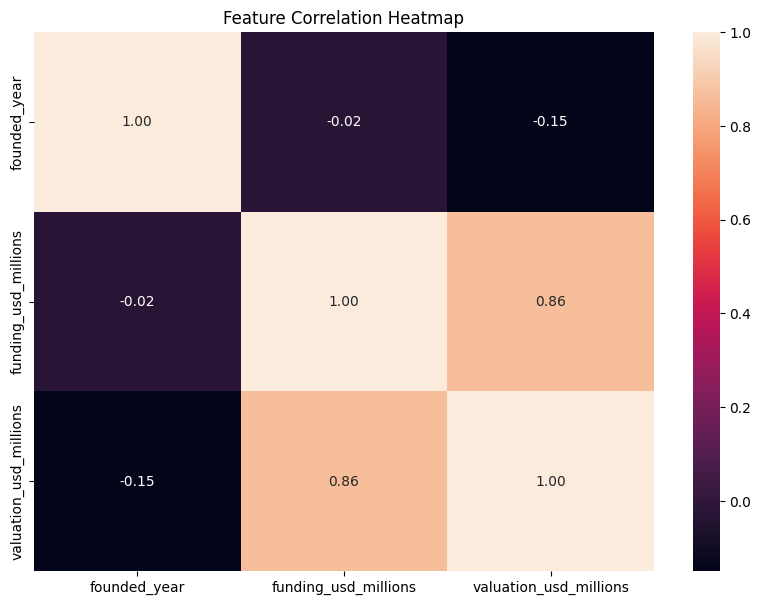

In [49]:
# Plot correlation heatmap

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

Save EDA Summary

Why: Save the important numerical EDA results for the project report.

In [50]:
# Create an EDA summary

eda_summary = pd.DataFrame({
    "metric": [
        "Total Records",
        "Total Columns",
        "Total Unicorn Records",
        "Total Non-Unicorn Records"
    ],
    "value": [
        len(df),
        len(df.columns),
        (df["is_unicorn"] == True).sum(),
        (df["is_unicorn"] == False).sum()
    ]
})

display(eda_summary)

,metric,value
0,Total Records,1383
1,Total Columns,14
2,Total Unicorn Records,1244
3,Total Non-Unicorn Records,101


Save Important Charts

Why: Store charts inside reports/figures/ so they can be shown in GitHub and the final project report.

In [51]:
# Create the figures folder

from pathlib import Path

figures_path = Path("../reports/figures")

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Figures folder ready. ✅")

Figures folder ready. ✅
